# VENTO: reproducible territorial screening workflow

This notebook reproduces the Colombian case-study risk score, relative categories, preliminary engagement modes, and weight-sensitivity analysis.

It reads only the two CSV files in `data/`. Sensitivity results are displayed in the notebook and saved only as PNG figures; no sensitivity CSV files are created.

The outputs support preliminary screening and planning. They do not authorize field entry, replace current security protocols, or exclude any community from consultation or participation.


In [1]:
# Import the libraries, define the repository-relative paths, and centralize the study parameters.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Resolve the repository root whether Jupyter starts here or one directory above it.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").is_dir() and (PROJECT_ROOT.parent / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
DATA_FILE = DATA_DIR / "dataset_completo.csv"
METADATA_FILE = DATA_DIR / "variables_metadata.csv"
FIGURE_DIR.mkdir(exist_ok=True)

SEED = 951
DENSITY_THRESHOLD = 15.0
BASE_WEIGHTS = np.array([0.35, 0.30, 0.20, 0.15])
COMPONENT_NAMES = ["Criminality index", "Armed groups", "Coca density (log)", "Coca proximity"]
CATEGORY_NAMES = np.array(["Low", "Medium", "High"])

assert DATA_FILE.exists(), f"Missing input file: {DATA_FILE}"
assert METADATA_FILE.exists(), f"Missing input file: {METADATA_FILE}"
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
# Load the municipal dataset and its data dictionary, then verify the minimum reproducibility requirements.
data = pd.read_csv(DATA_FILE, dtype={"COD_MPIO_DIVIPOLA": "string"})
metadata = pd.read_csv(METADATA_FILE)

required_columns = [
    "id_unificado",
    "COD_MPIO_DIVIPOLA",
    "nombre_departamento",
    "nombre_municipio",
    "indice_pena_media_0_100",
    "cantidad_grupos_armados_en_el_mpio",
    "densidad_cultivos_coca_ha_km2",
    "dist_min_coca_km",
    "densidad_pixeles_disponibles_pct_exacta",
]
missing_columns = sorted(set(required_columns) - set(data.columns))
missing_metadata = sorted(set(required_columns) - set(metadata["Variable"]))

assert not missing_columns, f"Missing dataset columns: {missing_columns}"
assert not missing_metadata, f"Missing metadata rows: {missing_metadata}"
assert len(data) == 1_122, f"Expected 1,122 municipalities; found {len(data):,}."
assert data["id_unificado"].is_unique, "id_unificado must be unique."
assert metadata["Variable"].is_unique, "The data dictionary contains duplicated variables."

display(pd.DataFrame({
    "Input": [DATA_FILE.name, METADATA_FILE.name],
    "Rows": [len(data), len(metadata)],
    "Columns": [data.shape[1], metadata.shape[1]],
}))


,Input,Rows,Columns
0,dataset_completo.csv,1122,47
1,variables_metadata.csv,47,12


## Baseline risk score

The four inputs are transformed, median-imputed when missing, standardized with population z-scores, and combined using the expert-derived Colombian weights. P50 and P75 are recalculated on the national reference universe for every weight vector.


In [3]:
# Recalculate the four score components, the normalized score, relative categories, and engagement modes.
def population_zscore(series):
    # Return a population z-score (ddof=0) and fail clearly for a constant input.
    standard_deviation = series.std(ddof=0)
    if np.isclose(standard_deviation, 0):
        raise ValueError(f"Cannot standardize constant series: {series.name}")
    return (series - series.mean()) / standard_deviation


def score_from_weights(z_matrix, weights):
    # Calculate the 0â€“1 score and relative category codes for one weight vector.
    weights = np.asarray(weights, dtype=float)
    if not np.all(weights > 0) or not np.isclose(weights.sum(), 1):
        raise ValueError("Weights must be positive and sum to one.")
    raw = z_matrix @ weights
    normalized = (raw - raw.min()) / (raw.max() - raw.min())
    p50, p75 = np.quantile(normalized, [0.50, 0.75])
    codes = np.where(normalized <= p50, 0, np.where(normalized <= p75, 1, 2)).astype(np.int8)
    return raw, normalized, codes, p50, p75


# Coerce the source variables to numeric values before applying the two nonlinear transformations.
inputs = data[[
    "indice_pena_media_0_100",
    "cantidad_grupos_armados_en_el_mpio",
    "densidad_cultivos_coca_ha_km2",
    "dist_min_coca_km",
]].apply(pd.to_numeric, errors="coerce")
components = pd.DataFrame({
    "criminality": inputs["indice_pena_media_0_100"],
    "armed_groups": inputs["cantidad_grupos_armados_en_el_mpio"],
    "coca_log": np.log1p(inputs["densidad_cultivos_coca_ha_km2"]),
    "coca_proximity": 1 / (1 + inputs["dist_min_coca_km"]),
})

# Median imputation is applied only to variables required by the score and remains auditable in memory.
imputation_flags = components.isna()
components_imputed = components.apply(lambda column: column.fillna(column.median()))
z_components = components_imputed.apply(population_zscore)
Z_MATRIX = z_components.to_numpy()

risk_raw, risk_score, baseline_codes, p50, p75 = score_from_weights(Z_MATRIX, BASE_WEIGHTS)
baseline_results = data[[
    "id_unificado", "COD_MPIO_DIVIPOLA", "nombre_departamento", "nombre_municipio",
    "densidad_pixeles_disponibles_pct_exacta",
]].copy()
baseline_results["risk_score"] = risk_score
baseline_results["relative_category"] = CATEGORY_NAMES[baseline_codes]
baseline_results["engagement_mode"] = baseline_results["relative_category"].map({
    "Low": "In-person, subject to verification",
    "Medium": "In-person with caution",
    "High": "Remote initial engagement",
})
baseline_results["selected_above_15pct"] = pd.to_numeric(
    baseline_results["densidad_pixeles_disponibles_pct_exacta"], errors="coerce"
).gt(DENSITY_THRESHOLD)

national_summary = baseline_results["relative_category"].value_counts().reindex(CATEGORY_NAMES)
selected_summary = baseline_results.loc[baseline_results["selected_above_15pct"], "relative_category"].value_counts().reindex(CATEGORY_NAMES).fillna(0).astype(int)
outcome_summary = pd.DataFrame({
    "National municipalities": national_summary,
    "Availability above 15%": selected_summary,
})

print(f"P50 = {p50:.8f}; P75 = {p75:.8f}")
print(f"Rows with at least one median-imputed score input: {imputation_flags.any(axis=1).sum():,}")
display(outcome_summary)

# These assertions protect the published case-study counts from unnoticed input or method changes.
assert national_summary.tolist() == [561, 280, 281]
assert selected_summary.tolist() == [76, 21, 14]


P50 = 0.28080170; P75 = 0.39816811
Rows with at least one median-imputed score input: 2


,National municipalities,Availability above 15%
relative_category,,
Low,561,76
Medium,280,21
High,281,14


## Deterministic sensitivity analysis

Each alternative changes the relative importance of the four components. The score, minâ€“max normalization, P50, P75, and categories are recalculated for every scenario.


,Design,P50,P75,Category agreement (%),Municipalities changing category,Spearman correlation
0,Baseline,0.2808,0.3982,100.0000,0,1.0000
1,Equal weights,0.2241,0.3380,94.4742,62,0.9916
2,Criminality dominant,0.3549,0.4626,89.1266,122,0.9749
3,Armed groups dominant,0.1930,0.3330,88.5918,128,0.9743
4,Illicit economies dominant,0.2250,0.3239,95.3654,52,0.9921
5,Coca proximity dominant,0.1539,0.2491,88.5027,129,0.9663


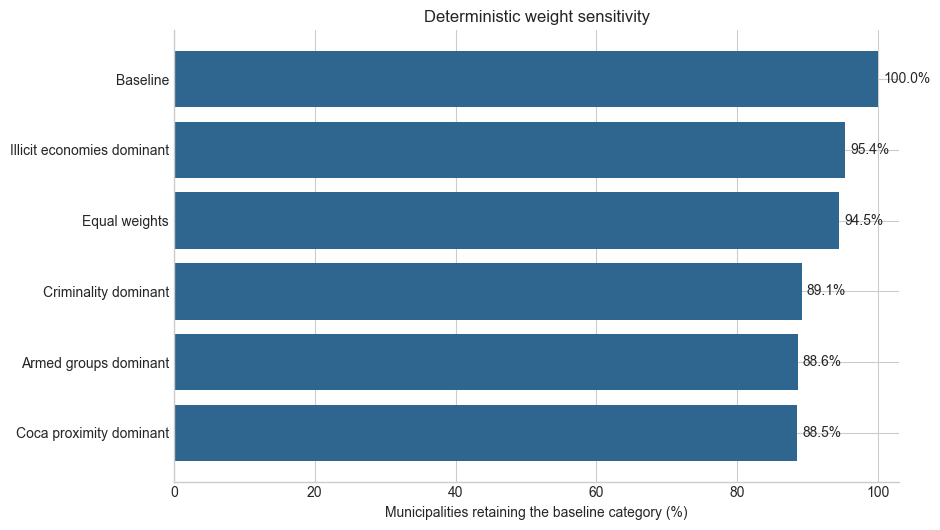

In [4]:
# Evaluate interpretable weight alternatives and save one compact agreement figure.
deterministic_designs = {
    "Baseline": [0.35, 0.30, 0.20, 0.15],
    "Equal weights": [0.25, 0.25, 0.25, 0.25],
    "Criminality dominant": [0.50, 0.25, 0.15, 0.10],
    "Armed groups dominant": [0.25, 0.50, 0.15, 0.10],
    "Illicit economies dominant": [0.25, 0.20, 0.35, 0.20],
    "Coca proximity dominant": [0.15, 0.20, 0.25, 0.40],
}

deterministic_rows = []
for name, weights in deterministic_designs.items():
    _, scenario_score, scenario_codes, scenario_p50, scenario_p75 = score_from_weights(Z_MATRIX, weights)
    deterministic_rows.append({
        "Design": name,
        "P50": scenario_p50,
        "P75": scenario_p75,
        "Category agreement (%)": (scenario_codes == baseline_codes).mean() * 100,
        "Municipalities changing category": int((scenario_codes != baseline_codes).sum()),
        "Spearman correlation": pd.Series(scenario_score).rank().corr(pd.Series(risk_score).rank()),
    })

deterministic_summary = pd.DataFrame(deterministic_rows)
display(deterministic_summary.round(4))

plot_data = deterministic_summary.sort_values("Category agreement (%)")
fig, ax = plt.subplots(figsize=(9.5, 5.4))
bars = ax.barh(plot_data["Design"], plot_data["Category agreement (%)"], color="#2F6690")
ax.set_xlim(0, 103)
ax.set_xlabel("Municipalities retaining the baseline category (%)")
ax.set_title("Deterministic weight sensitivity")
for bar, agreement in zip(bars, plot_data["Category agreement (%)"]):
    ax.text(agreement + 0.7, bar.get_y() + bar.get_height() / 2, f"{agreement:.1f}%", va="center")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_deterministic_agreement.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


## Probabilistic sensitivity analysis

Three Dirichlet designs explore moderate, broad, and fully uniform uncertainty in the weights. Each design uses 50,000 iterations. Simulations run in batches to limit memory use, and no municipality-level sensitivity files are exported.


In [5]:
# Run the 50,000-iteration designs in batches and retain only the summaries needed for figures and auditing.
N_ITERATIONS = 50_000
BATCH_SIZE = 1_000


def simulate_dirichlet(name, alpha, seed):
    # Accumulate category probabilities and transitions without storing score matrices.
    rng = np.random.default_rng(seed)
    category_counts = np.zeros((len(data), 3), dtype=np.int64)
    transitions = np.zeros((3, 3), dtype=np.int64)
    sampled_weights = np.empty((N_ITERATIONS, 4), dtype=float)

    start = 0
    while start < N_ITERATIONS:
        batch_size = min(BATCH_SIZE, N_ITERATIONS - start)
        weights = rng.dirichlet(alpha, size=batch_size)
        sampled_weights[start:start + batch_size] = weights

        raw = Z_MATRIX @ weights.T
        normalized = (raw - raw.min(axis=0)) / (raw.max(axis=0) - raw.min(axis=0))
        q50, q75 = np.quantile(normalized, [0.50, 0.75], axis=0)
        categories = np.where(normalized <= q50, 0, np.where(normalized <= q75, 1, 2)).astype(np.int8)

        for code in range(3):
            category_counts[:, code] += (categories == code).sum(axis=1)
        for baseline_code in range(3):
            transitions[baseline_code] += np.bincount(
                categories[baseline_codes == baseline_code].ravel(), minlength=3
            )
        start += batch_size

    probabilities = category_counts / N_ITERATIONS
    baseline_probability = probabilities[np.arange(len(data)), baseline_codes]
    robustness = np.select(
        [baseline_probability >= 0.90, baseline_probability >= 0.60],
        ["Robust", "Sensitive"],
        default="Uncertain",
    )
    return {
        "name": name,
        "alpha": np.asarray(alpha),
        "weights": sampled_weights,
        "probabilities": probabilities,
        "baseline_probability": baseline_probability,
        "robustness": robustness,
        "transitions": transitions,
    }


monte_carlo_designs = [
    ("Moderate, centered (k=50)", BASE_WEIGHTS * 50, 951),
    ("Broad, centered (k=10)", BASE_WEIGHTS * 10, 1951),
    ("Uniform (1, 1, 1, 1)", np.ones(4), 2951),
]
simulation_results = {
    name: simulate_dirichlet(name, alpha, seed)
    for name, alpha, seed in monte_carlo_designs
}

monte_carlo_rows = []
for name, _, _ in monte_carlo_designs:
    result = simulation_results[name]
    counts = pd.Series(result["robustness"]).value_counts().reindex(["Robust", "Sensitive", "Uncertain"]).fillna(0)
    monte_carlo_rows.append({
        "Weight design": name,
        "Mean baseline-category agreement (%)": result["baseline_probability"].mean() * 100,
        "Robust municipalities (%)": counts["Robust"] / len(data) * 100,
        "Sensitive municipalities (%)": counts["Sensitive"] / len(data) * 100,
        "Uncertain municipalities (%)": counts["Uncertain"] / len(data) * 100,
    })

monte_carlo_summary = pd.DataFrame(monte_carlo_rows)
display(monte_carlo_summary.round(2))


,Weight design,Mean baseline-category agreement (%),Robust municipalities (%),Sensitive municipalities (%),Uncertain municipalities (%)
0,"Moderate, centered (k=50)",94.83,84.22,11.85,3.92
1,"Broad, centered (k=10)",89.65,69.16,22.10,8.73
2,"Uniform (1, 1, 1, 1)",85.55,57.66,30.04,12.30


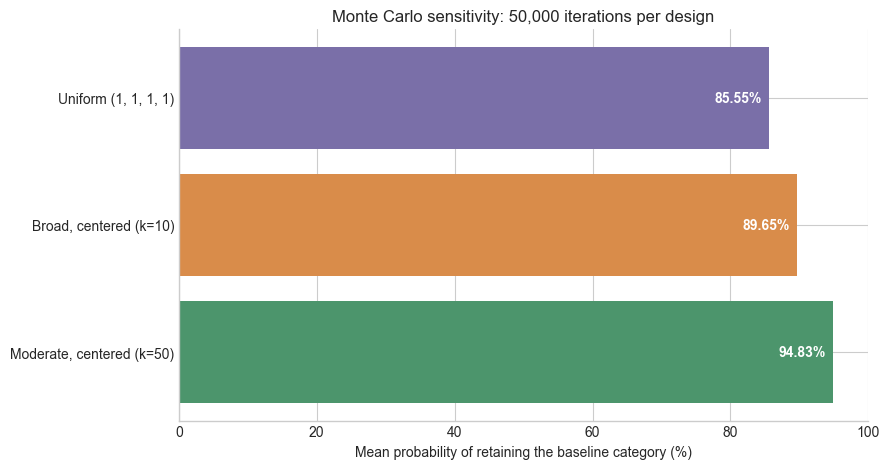

In [6]:
# Plot mean category agreement across the three probabilistic weight designs.
fig, ax = plt.subplots(figsize=(9, 4.8))
agreement = monte_carlo_summary["Mean baseline-category agreement (%)"]
bars = ax.barh(monte_carlo_summary["Weight design"], agreement, color=["#4C956C", "#D98C4A", "#7A6FA8"])
ax.set_xlim(0, 100)
ax.set_xlabel("Mean probability of retaining the baseline category (%)")
ax.set_title("Monte Carlo sensitivity: 50,000 iterations per design")
for bar, value in zip(bars, agreement):
    ax.text(value - 1.0, bar.get_y() + bar.get_height() / 2, f"{value:.2f}%", ha="right", va="center", color="white", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_monte_carlo_agreement.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


,Selected municipalities
Robust,96
Sensitive,10
Uncertain,5


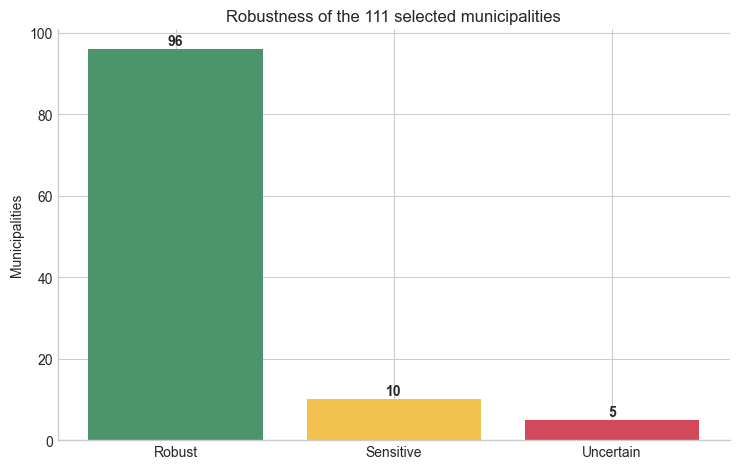

In [7]:
# Summarize robustness for the 111 selected municipalities under moderate perturbations and save the figure.
moderate = simulation_results["Moderate, centered (k=50)"]
selected_mask = baseline_results["selected_above_15pct"].to_numpy()
selected_robustness = pd.Series(moderate["robustness"][selected_mask])
selected_counts = selected_robustness.value_counts().reindex(["Robust", "Sensitive", "Uncertain"]).fillna(0).astype(int)
display(selected_counts.to_frame("Selected municipalities"))

fig, ax = plt.subplots(figsize=(7.5, 4.8))
bars = ax.bar(selected_counts.index, selected_counts.values, color=["#4C956C", "#F2C14E", "#D1495B"])
ax.set_ylabel("Municipalities")
ax.set_title("Robustness of the 111 selected municipalities")
for bar, value in zip(bars, selected_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1, str(value), ha="center", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_selected_municipalities_robustness.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

assert selected_counts.tolist() == [96, 10, 5]


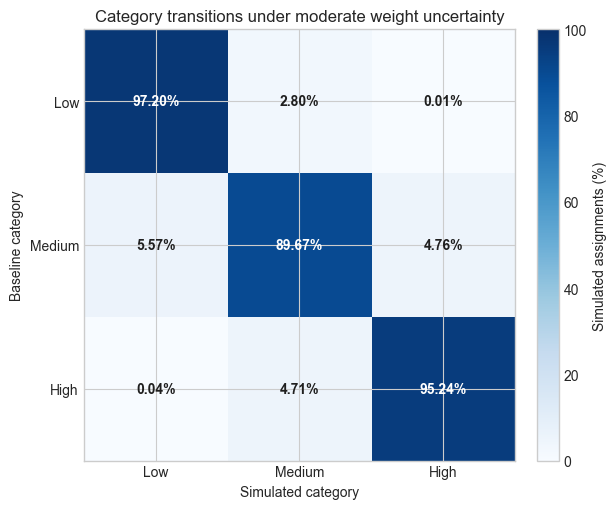

In [8]:
# Visualize the moderate-design transition probabilities between baseline and simulated categories.
transition_percent = moderate["transitions"] / moderate["transitions"].sum(axis=1, keepdims=True) * 100
fig, ax = plt.subplots(figsize=(6.5, 5.2))
image = ax.imshow(transition_percent, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(3), CATEGORY_NAMES)
ax.set_yticks(range(3), CATEGORY_NAMES)
ax.set_xlabel("Simulated category")
ax.set_ylabel("Baseline category")
ax.set_title("Category transitions under moderate weight uncertainty")
for row in range(3):
    for column in range(3):
        value = transition_percent[row, column]
        ax.text(column, row, f"{value:.2f}%", ha="center", va="center", color="white" if value > 50 else "#1F1F1F", fontweight="bold")
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Simulated assignments (%)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_moderate_transition_matrix.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


In [9]:
# Run compact reproducibility checks and stop if any core result is inconsistent.
alternative_agreement = deterministic_summary.loc[
    deterministic_summary["Design"].ne("Baseline"), "Category agreement (%)"
]
audit_checks = {
    "Baseline weights are positive and sum to one": bool((BASE_WEIGHTS > 0).all() and np.isclose(BASE_WEIGHTS.sum(), 1)),
    "National category counts equal 561/280/281": national_summary.tolist() == [561, 280, 281],
    "Selected category counts equal 76/21/14": selected_summary.tolist() == [76, 21, 14],
    "Deterministic alternatives span 88.50%â€“95.37% agreement": np.isclose(alternative_agreement.min(), 88.5026737968) and np.isclose(alternative_agreement.max(), 95.3654188948),
    "Moderate selected robustness equals 96/10/5": selected_counts.tolist() == [96, 10, 5],
    "All simulated weight vectors sum to one": all(np.allclose(result["weights"].sum(axis=1), 1) for result in simulation_results.values()),
    "All municipal category probabilities sum to one": all(np.allclose(result["probabilities"].sum(axis=1), 1) for result in simulation_results.values()),
    "Each transition matrix contains all simulated assignments": all(int(result["transitions"].sum()) == len(data) * N_ITERATIONS for result in simulation_results.values()),
}
audit = pd.DataFrame({"Check": audit_checks.keys(), "Passed": audit_checks.values()})
display(audit)
assert audit["Passed"].all(), "At least one reproducibility check failed."
print("Audit passed. Figures were saved to figures/.")


,Check,Passed
0,Baseline weights are positive and sum to one,True
1,National category counts equal 561/280/281,True
2,Selected category counts equal 76/21/14,True
3,Deterministic alternatives span 88.50%â€“95.37...,True
4,Moderate selected robustness equals 96/10/5,True
5,All simulated weight vectors sum to one,True
6,All municipal category probabilities sum to one,True
7,Each transition matrix contains all simulated ...,True


Audit passed. Figures were saved to figures/.


## Interpretation and responsible use

- The percentile categories are relative to the 1,122-municipality reference universe.
- A low relative category does not establish that physical entry is safe.
- The engagement mode is a preliminary planning recommendation and requires current institutional and local verification.
- Remote initial engagement must not reduce participation or consultation; accessible channels and trusted intermediaries remain necessary.
- Sensitivity results identify classifications that deserve additional expert and territorial validation.
